In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (
            brier_score_loss,    #to check if  model's probabilities are accurate. Brier score tells you if the number it gives you is trustworthy.
            roc_auc_score
)
from sklearn.calibration import calibration_curve

In [2]:
model = joblib.load("../models/physionet_lightgbm.pkl")

print("PhysioNet LightGBM model loaded successfully!")

PhysioNet LightGBM model loaded successfully!


In [3]:
external = pd.read_csv(
    "../data/processed/external_feature_dataset.csv",
)
print(" External dataset shape: ", external.shape)
external.head()


 External dataset shape:  (40336, 201)


,HR_mean,HR_min,HR_max,HR_std,HR_last,O2Sat_mean,O2Sat_min,O2Sat_max,O2Sat_std,O2Sat_last,...,HospAdmTime_min,HospAdmTime_max,HospAdmTime_std,HospAdmTime_last,ICULOS_mean,ICULOS_min,ICULOS_max,ICULOS_std,ICULOS_last,SepsisLabel
0,101.571429,76.0,117.0,9.594378,84.0,91.477273,85.0,100.0,3.460667,85.0,...,-0.03,-0.03,3.502025e-18,-0.03,27.5,1,54,15.732133,54,0
1,60.954545,54.0,94.0,8.144395,55.0,97.000000,94.0,100.0,2.138090,95.0,...,-98.60,-98.60,2.906048e-14,-98.60,12.0,1,23,6.782330,23,0
2,79.611111,68.0,93.0,6.714036,78.0,95.431818,91.0,99.0,1.655122,97.0,...,-1195.71,-1195.71,0.000000e+00,-1195.71,24.5,1,48,14.000000,48,0
3,102.444444,93.0,113.0,6.337212,NaN,98.203704,95.5,100.0,1.449531,NaN,...,-8.77,-8.77,1.807799e-15,-8.77,15.0,1,29,8.514693,29,0
4,73.916667,61.0,88.0,7.586697,NaN,97.500000,96.0,99.0,0.741620,NaN,...,-0.05,-0.05,7.012323e-18,-0.05,25.5,2,49,14.000000,49,0


In [4]:
model_feature = model.feature_name_
X_external = external[model_feature]
y_external = external["SepsisLabel"]
print("X_external:", X_external.shape)
print("y_external:", y_external.shape)

X_external: (40336, 200)
y_external: (40336,)


In [5]:
y_prob = model.predict_proba(X_external)[:, 1]

print("Probability predictions generated.")
print("Minimum probability:", y_prob.min())
print("Maximum probability:", y_prob.max())
print("Mean probability:", y_prob.mean())

Probability predictions generated.
Minimum probability: 0.00023114109302467667
Maximum probability: 0.9988992826271818
Mean probability: 0.07464315933147957


In [6]:
brier = brier_score_loss(
    y_external,
    y_prob
)

print("Brier Score:", brier)

Brier Score: 0.02393063049136526


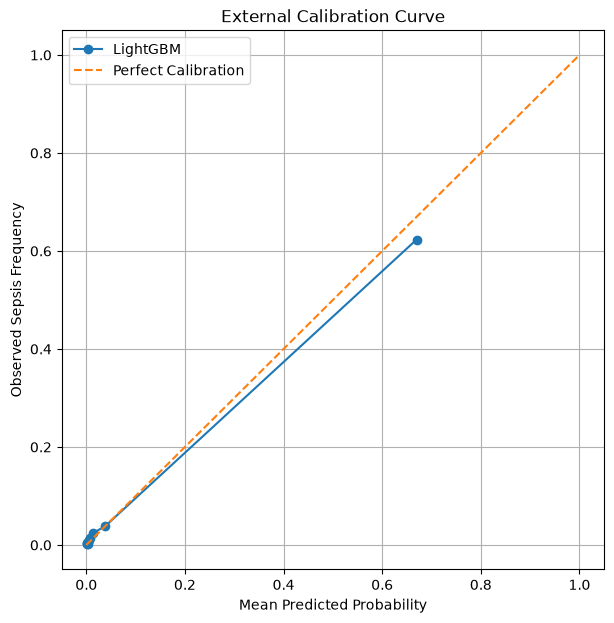

In [7]:
prob_true, prob_pred = calibration_curve(
    y_external,
    y_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 7))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="LightGBM"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Sepsis Frequency")
plt.title("External Calibration Curve")
plt.legend()
plt.grid(True)

plt.show()

In [11]:
calibration_table = pd.DataFrame({
    "Predicted_Probability": prob_pred,
    "Observed_Frequency": prob_true
})

calibration_table["Calibration_Error"] = (
    calibration_table["Observed_Frequency"]
    - calibration_table["Predicted_Probability"]
)

calibration_table
### if the table has more postive value then the model is underconfident because the observed - predicted is high which denotes the model give false negative and if the model calibration error has high negative then this denotes the model is over confident

,Predicted_Probability,Observed_Frequency,Calibration_Error
0,0.000745,0.001239,0.000494
1,0.001316,0.003471,0.002155
2,0.001937,0.003967,0.002031
3,0.002714,0.002231,-0.000483
4,0.003785,0.006199,0.002413
5,0.005425,0.009916,0.004490
6,0.008279,0.013637,0.005359
7,0.014379,0.024789,0.010410
8,0.038133,0.038185,0.000052
9,0.669656,0.623203,-0.046454


In [9]:
print("Maximum calibration error:",
      calibration_table["Calibration_Error"].abs().max())

print("Mean absolute calibration error:",
      calibration_table["Calibration_Error"].abs().mean())

Maximum calibration error: 0.04645369129397492
Mean absolute calibration error: 0.007434095657872977
